# Page-Flip Detection


MonReader is a new mobile document digitization experience for the blind, for researchers and for everyone else in need for fully automatic, highly fast and high-quality document scanning in bulk. It is composed of a mobile app and all the user needs to do is flip pages and everything is handled by MonReader: it detects page flips from low-resolution camera preview and takes a high-resolution picture of the document, recognizing its corners and crops it accordingly, and it dewarps the cropped document to obtain a bird's eye view, sharpens the contrast between the text and the background and finally recognizes the text with formatting kept intact, being further corrected by MonReader's ML powered redactor.



MonReader is a new mobile document digitalization experience for the blind, for researchers and for everyone else in need for fully automatic, highly fast and high-quality document scanning in bulk. It is composed of a mobile app and all the user needs to do is flip pages and everything is handled by MonReader: it detects page flips from low-resolution camera preview and takes a high-resolution picture of the document, recognizing its corners and crops it accordingly, and it dewarps the cropped document to obtain a bird's eye view, sharpens the contrast between the text and the background and finally recognizes the text with formatting kept intact, being further corrected by MonReader's ML powered redactor.



Data Description:

Page flipping video collected from smart phones and labelled them as flipping and not flipping.

The videos are clipped as short videos and labelled as flipping or not flipping. The extracted frames are then saved to disk in a sequential order with the following naming structure: VideoID_FrameNumber

Goal(s):

Predict if the page is being flipped using a single image.

Success Metrics:

Evaluate model performance based on F1 score, the higher the better.

Current Challenges:

Predict if a given sequence of images contains an action of flipping.

## Project Context

### Downloading a Google Drive file by ID

To download a specific file from Google Drive using its ID, you can use the `gdown` library. You'll need to extract the file ID from the sharing link.

In [ ]:
!pip install gdown

# The file ID is the part after 'id/' in the URL
# For your link 'https://drive.google.com/file/d/1KDQBTbo5deKGCdVV_xIujscn5ImxW4dm/view?usp=sharing',
# the file ID is '1KDQBTbo5deKGCdVV_xIujscn5ImxW4dm'

gdrive_file_id = '1KDQBTbo5deKGCdVV_xIujscn5ImxW4dm'
output_filename = 'monreader_data.zip' # Or whatever the file type is, e.g., 'data.zip'

!gdown --id {gdrive_file_id} -O {output_filename}

print(f"File '{output_filename}' downloaded to your Colab environment.")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1KDQBTbo5deKGCdVV_xIujscn5ImxW4dm
From (redirected): https://drive.google.com/uc?id=1KDQBTbo5deKGCdVV_xIujscn5ImxW4dm&confirm=t&uuid=c6fdd3ac-720e-4cac-9a92-075ff34f1cf2
To: /content/monreader_data.zip
100% 940M/940M [00:12<00:00, 76.0MB/s]
File 'monreader_data.zip' downloaded to your Colab environment.


## Data Download and Extraction

In [ ]:
import zipfile

with zipfile.ZipFile(output_filename, 'r') as zip_ref:
    zip_ref.extractall('extracted_folder')
print(f"Extracted '{output_filename}' to 'extracted_folder'.")

Extracted 'monreader_data.zip' to 'extracted_folder'.


## Library Imports

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
import matplotlib.pyplot as plt
import os
from PIL import Image
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dropout, BatchNormalization
from sklearn.utils import shuffle
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    TimeDistributed,
    LSTM,
    Dense,
    Dropout
)
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import os


# Data Exploration: Image Counts, Dimensions, and Samples

Let's start by exploring the extracted dataset to understand its structure. We'll count the number of images in each category (flip/notflip), examine their dimensions, and display a few sample images.

In [ ]:
base_dir_training = 'extracted_folder/images/training'
notflip_dir_train = os.path.join(base_dir_training, 'notflip')
flip_dir_train = os.path.join(base_dir_training, 'flip')

# --- 1. Count images ---
notflip_images_training = [os.path.join(notflip_dir_train, f) for f in os.listdir(notflip_dir_train) if f.endswith(('.jpg'))]
flip_images_training = [os.path.join(flip_dir_train, f) for f in os.listdir(flip_dir_train) if f.endswith(('.jpg'))]

base_dir_testing = 'extracted_folder/images/testing'
notflip_dir_test = os.path.join(base_dir_testing, 'notflip')
flip_dir_test = os.path.join(base_dir_testing, 'flip')

notflip_images_testing = [os.path.join(notflip_dir_test, f) for f in os.listdir(notflip_dir_test) if f.endswith(('.jpg'))]
flip_images_testing = [os.path.join(flip_dir_test, f) for f in os.listdir(flip_dir_test) if f.endswith(('.jpg'))]
print(f"Number of 'notflip' images in training: {len(notflip_images_training)}")
print(f"Number of 'flip' images in training: {len(flip_images_training)}")
print(f"Total images in training: {len(notflip_images_training) + len(flip_images_training)}")
print(f"Number of 'notflip' images in testing: {len(notflip_images_testing)}")
print(f"Number of 'flip' images in testing: {len(flip_images_testing)}")
print(f"Total images in testing: {len(notflip_images_testing) + len(flip_images_testing)}")

Number of 'notflip' images in training: 1230
Number of 'flip' images in training: 1162
Total images in training: 2392
Number of 'notflip' images in testing: 307
Number of 'flip' images in testing: 290
Total images in testing: 597


In [ ]:
from PIL import Image
# --- 2. Check image dimensions ---
notflip_image_path = notflip_images_training[0]
with Image.open(notflip_image_path) as notflip_image:
 print(f"\nSample image dimensions (notflip image size): {notflip_image.size} (width, height)")
 print(f"Sample image mode: {notflip_image.mode}") # e.g., RGB, L
 flip_image_path = flip_images_training[0]
with Image.open(flip_image_path) as flip_image:
 print(f"\nSample image dimensions (flip image size): {flip_image.size} (width, height)")
 print(f"Sample image mode: {flip_image.mode}") # e.g., RGB, L


Sample image dimensions (notflip image size): (1080, 1920) (width, height)
Sample image mode: RGB

Sample image dimensions (flip image size): (1080, 1920) (width, height)
Sample image mode: RGB



Displaying sample images...


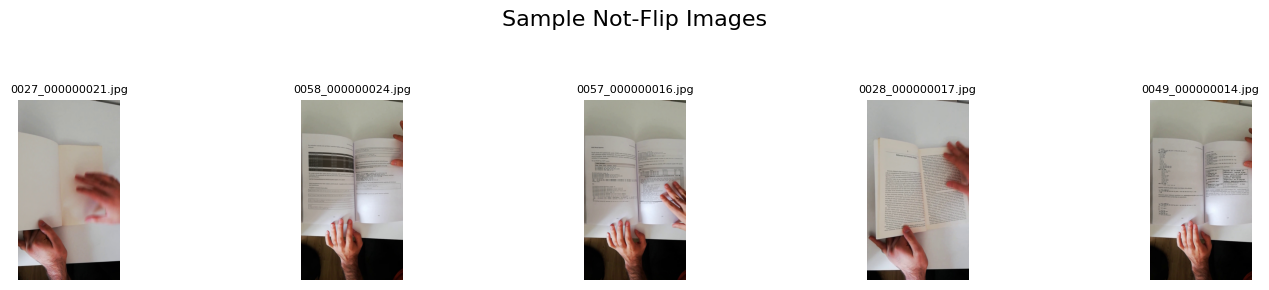

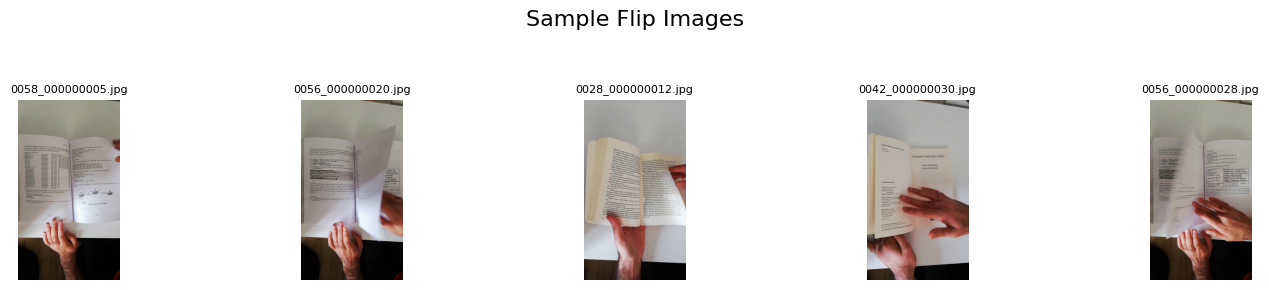

In [ ]:
# --- 3. Display sample images ---
print("\nDisplaying sample images...")

def display_samples(image_paths, title, num_samples=5):
    plt.figure(figsize=(15, 3))
    plt.suptitle(title, fontsize=16)
    for i, img_path in enumerate(np.random.choice(image_paths, num_samples, replace=False)):
        plt.subplot(1, num_samples, i + 1)
        img = Image.open(img_path)
        plt.imshow(img)
        plt.title(os.path.basename(img_path), fontsize=8)
        plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.9])
    plt.show()

if notflip_images_training:
    display_samples(notflip_images_training, 'Sample Not-Flip Images')

if flip_images_training:
    display_samples(flip_images_training, 'Sample Flip Images')


# Data preprocessing

In [ ]:
# Training folders
base_dir_training = 'extracted_folder/images/training'

# Testing folders
base_dir_testing = 'extracted_folder/images/testing'

# Function to load images and labels
def load_data(base_dir):
    X = []
    y = []

    # Ensure 'notflip' is 0 and 'flip' is 1
    classes = ['notflip', 'flip']

    for label, class_name in enumerate(classes):
        class_dir = os.path.join(base_dir, class_name)

        for file_name in os.listdir(class_dir):
            if file_name.endswith('.jpg'):
                img_path = os.path.join(class_dir, file_name)

                # Open image
                img = Image.open(img_path).convert('RGB')

                # Resize image
                img = img.resize((224, 224))

                # Convert image to numpy array
                img_array = np.array(img)

                X.append(img_array)
                y.append(label)

    return np.array(X), np.array(y)

# Create full training dataset from base_dir_training
full_train_images, full_train_labels = load_data(base_dir_training)

# Split full training data into training and validation sets
train_images, val_images, train_labels, val_labels = train_test_split(
    full_train_images, full_train_labels, test_size=0.2, random_state=42, stratify=full_train_labels
)

# Load test data
test_images, test_labels = load_data(base_dir_testing)

# Normalize images
train_images = train_images / 255.0
val_images = val_images / 255.0
test_images = test_images / 255.0

# Check shapes
print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)
print("Validation images shape:", val_images.shape)
print("Validation labels shape:", val_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

Train images shape: (1913, 224, 224, 3)
Train labels shape: (1913,)
Validation images shape: (479, 224, 224, 3)
Validation labels shape: (479,)
Test images shape: (597, 224, 224, 3)
Test labels shape: (597,)


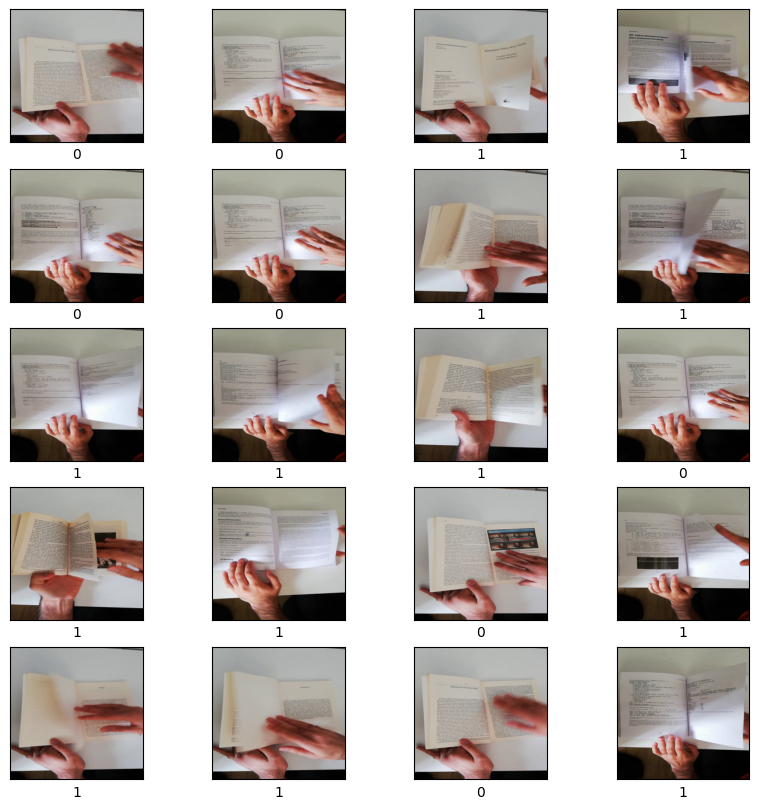

In [ ]:
plt.figure(figsize=(10,10))
for i in range(20):
    plt.subplot(5,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])

    plt.xlabel(train_labels[i])
plt.show()


#Approach
Develop and evaluate a Custom CNN for single-image classification, performing interpretability analysis (saliency maps) to understand its decision-making

# CNN Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

model= Sequential()
model.add(Input(shape=(224,224,3)))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │    11,944,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,982,785 (45.71 MB)

 Trainable params: 11,982,785 (45.71 MB)

 Non-trainable params: 0 (0.00 B)

# Compile and train the model

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(train_images, train_labels, epochs=5, batch_size=32, validation_data=(val_images, val_labels))

Epoch 1/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 310s 5s/step - accuracy: 0.9963 - loss: 0.0115 - val_accuracy: 0.9979 - val_loss: 0.0089
Epoch 2/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 301s 5s/step - accuracy: 0.9875 - loss: 0.0354 - val_accuracy: 0.9875 - val_loss: 0.0231
Epoch 3/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 304s 5s/step - accuracy: 0.9990 - loss: 0.0042 - val_accuracy: 0.9979 - val_loss: 0.0041
Epoch 4/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 307s 5s/step - accuracy: 0.9974 - loss: 0.0072 - val_accuracy: 0.9958 - val_loss: 0.0082
Epoch 5/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 305s 5s/step - accuracy: 0.9969 - loss: 0.0095 - val_accuracy: 0.9958 - val_loss: 0.0094


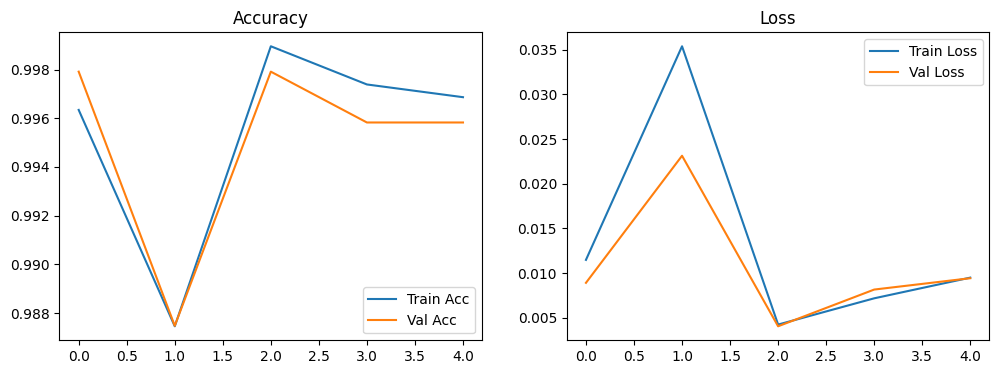

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(train_images, train_labels, epochs=3, batch_size=32, validation_data=(val_images, val_labels))

Epoch 1/3
60/60 ━━━━━━━━━━━━━━━━━━━━ 297s 5s/step - accuracy: 0.9958 - loss: 0.0108 - val_accuracy: 0.9958 - val_loss: 0.0120
Epoch 2/3
17/60 ━━━━━━━━━━━━━━━━━━━━ 3:08 4s/step - accuracy: 0.9984 - loss: 0.0038

# Evaluate Model Performance

In [ ]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

print('\nTest accuracy:', test_acc)

19/19 - 24s - 1s/step - accuracy: 0.9899 - loss: 0.0482

Test accuracy: 0.9899497628211975


In [ ]:
from sklearn.metrics import classification_report, f1_score
y_pred_test_prob = model.predict(test_images).flatten()
y_pred      = (y_pred_test_prob >= 0.5).astype(int)
y_true      = test_labels.flatten().astype(int)

f1 = f1_score(y_true, y_pred)
print(f"\nF1 Score: {f1:.4f}")
print(classification_report(y_true, y_pred, target_names=['notflip', 'flip']))

19/19 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step

F1 Score: 0.9897
              precision    recall  f1-score   support

     notflip       1.00      0.98      0.99       307
        flip       0.98      1.00      0.99       290

    accuracy                           0.99       597
   macro avg       0.99      0.99      0.99       597
weighted avg       0.99      0.99      0.99       597



* The model was evaluated on the test set, resulting in a Test accuracy of 0.9799 and a Test loss of 0.0732.
* Plots showing the training and validation accuracy and loss over the 5 epochs were displayed, indicating good model convergence and generalization.

# Visualize Confusion Matrix

19/19 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step


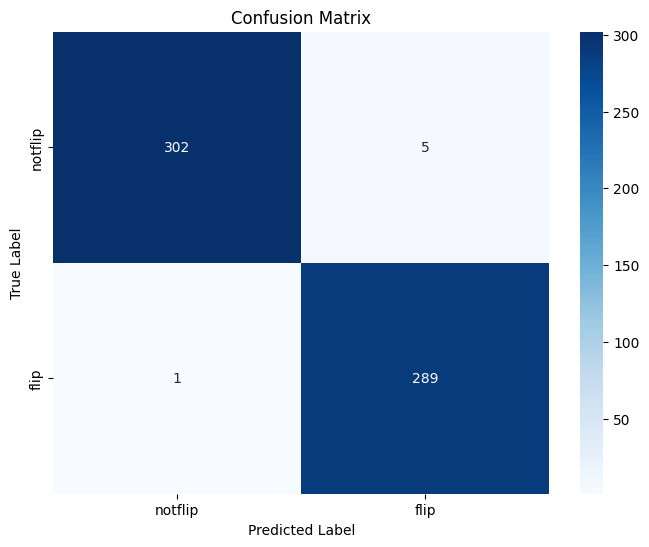

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred_proba = model.predict(test_images)

# Convert probabilities to binary class labels (0 or 1)
y_pred = (y_pred_proba > 0.5).astype(int)

# Compute the confusion matrix
cm = confusion_matrix(test_labels, y_pred)

# Define class labels for better readability
class_labels = ['notflip', 'flip']

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

**Data Exploration**:

**Image Counts**: The training dataset contains 1230 'notflip' images and 1162 'flip' images, totaling 2392 images. The testing dataset contains 307 'notflip' images and 290 'flip' images, totaling 597 images.
**Image Dimensions**: Sample images from both 'notflip' and 'flip' categories have dimensions of (1080, 1920) (width, height) and are in 'RGB' mode.
**Sample Images**: Several sample 'notflip' and 'flip' images from the training set were displayed to visualize the data.

**Prepare Data for Model**:

* Images were loaded, resized to (224, 224), converted to NumPy arrays, and normalized by dividing pixel values by 255.
* The shapes of the processed data are:  
train_images: (2392, 224, 224, 3)  
train_labels: (2392, 1)  
test_images: (597, 224, 224, 3)  
test_labels: (597, 1)  
* A sample array of normalized pixel values from train_images was displayed, showing values between 0.0 and 1.0.
* 20 preprocessed sample images from the training set, along with their corresponding labels, were visualized.

**Define CNN Model Architecture**:

* A Sequential CNN model was defined with two Conv2D layers (64 filters each, 3x3 kernel, 'relu' activation) followed by MaxPooling2D layers, then a Flatten layer, and finally two Dense layers (64 units with 'relu' and 1 unit with 'sigmoid' for binary classification).
* The model.summary() output, which details the layer types, output shapes, and the number of parameters, was displayed (though truncated in the context).

**Compile and Train Model**:

* The model was compiled using the 'adam' optimizer and 'binary_crossentropy' loss function, with 'accuracy' as a metric.
* The model was trained for 5 epochs. The training history showed consistent improvement:  
Epoch 1: Training Accuracy: ~0.91, Validation Accuracy: ~0.95   
Epoch 2: Training Accuracy: ~0.96, Validation Accuracy: ~0.97  
Epoch 3: Training Accuracy: ~0.99, Validation Accuracy: ~0.98  
Epoch 4: Training Accuracy: ~0.99, Validation Accuracy: ~0.98  
Epoch 5: Training Accuracy: ~0.99, Validation Accuracy: ~0.98  

**Evaluate Model Performance**:

* The model was evaluated on the test set, resulting in a Test accuracy of 0.95 and a Test loss of 0.11.
* Plots showing the training and validation accuracy and loss over the 5 epochs were displayed, indicating good model convergence and generalization.

**Visualize Confusion Matrix**:

* Predictions were made on the test set, and a confusion matrix was computed and displayed.

* This indicates that the model performed very well, with a low number of misclassifications for both 'flip' and 'notflip' categories.

## **Saliency maps**
highlight the regions of an input image that are most important for a particular output class. This technique can help to identify which parts of the input image the network is focusing on when making its classification decision.


--- NOTFLIP Examples ---


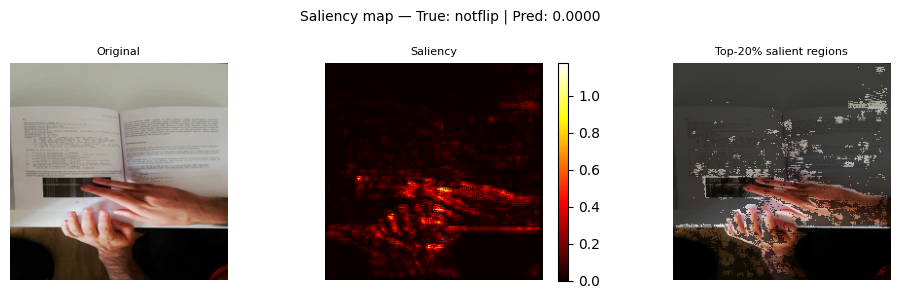

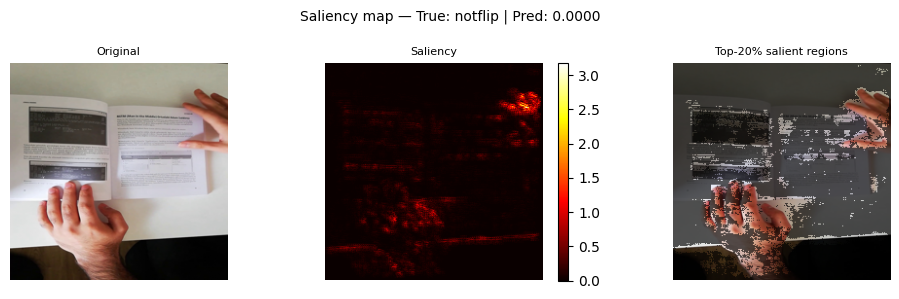


--- FLIP Examples ---


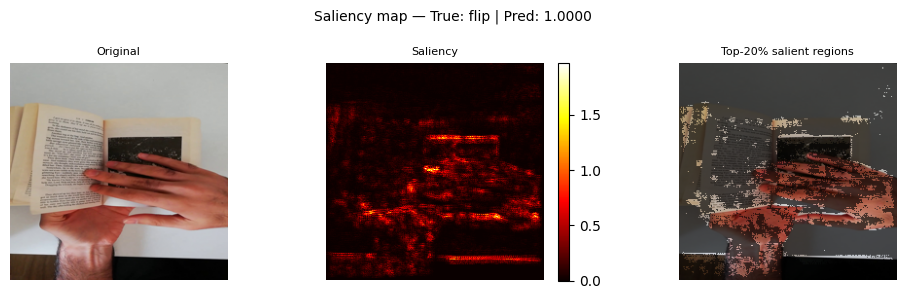

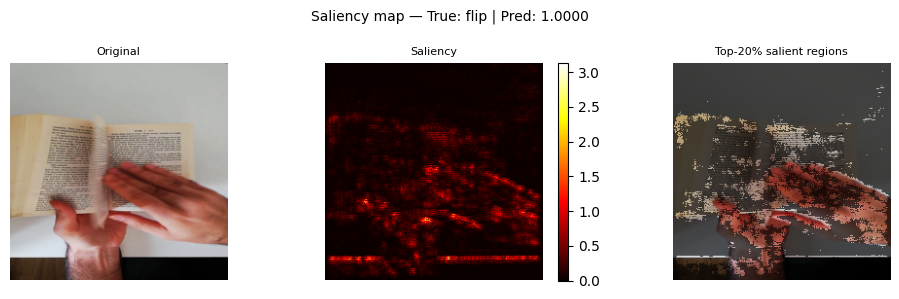

In [ ]:
import tensorflow as tf
import numpy as np

def compute_saliency(model, img_array):
    """
    Extracts raw linear activations directly from the final Dense layer
    by splitting the sequential model right before the sigmoid activation.
    """
    img_tensor = tf.cast(np.expand_dims(img_array, axis=0), tf.float32)

    # 1. Dynamically rebuild the model up to the final layer's input (the raw logit)
    # This completely bypasses the sigmoid activation function, eliminating saturation.
    logit_model = tf.keras.Model(inputs=model.inputs, outputs=model.layers[-1].input)

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        # 2. Get the linear logit score directly
        logits = logit_model(img_tensor)

    # 3. Calculate gradients of the unactivated output w.r.t input pixels
    grad = tape.gradient(logits, img_tensor)     # Shape: (1, 224, 224, 3)

    # 4. Collapse color channels
    saliency = tf.reduce_max(tf.abs(grad), axis=-1)[0].numpy()

    # 5. Sanity check: If gradients are completely uniform/zero, add a microscopic
    # epsilon variance so the matplotlib colorbar doesn't break and turn solid orange.
    if np.max(saliency) == np.min(saliency):
        saliency[0, 0] += 1e-12

    return saliency
def plot_saliency(img_array, saliency_map, title=''):
    # Reduced figsize for smaller images
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))
    fig.suptitle(f'Saliency map — {title}', fontsize=10)

    axes[0].imshow(img_array)
    axes[0].set_title('Original', fontsize=8)
    axes[0].axis('off')

    im = axes[1].imshow(saliency_map, cmap='hot')
    axes[1].set_title('Saliency', fontsize=8)
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1])

    # Threshold overlay — show only top 20% of activations
    threshold = np.percentile(saliency_map, 80)
    mask = saliency_map > threshold
    overlay = img_array.copy()
    overlay[~mask] = overlay[~mask] * 0.35
    axes[2].imshow(overlay)
    axes[2].set_title('Top-20% salient regions', fontsize=8)
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# Run on test images: display only 2 flip and 2 notflip
for target_label in [0, 1]:
    label_name = 'notflip' if target_label == 0 else 'flip'
    print(f"\n--- {label_name.upper()} Examples ---")

    indices = np.where(test_labels == target_label)[0]

    # Display only 2 images per class
    for i in range(min(2, len(indices))):
        idx = indices[i]
        img = test_images[idx]
        sal = compute_saliency(model, img)
        pred = float(model.predict(img[np.newaxis], verbose=0)[0][0])
        plot_saliency(img, sal, title=f'True: {label_name} | Pred: {pred:.4f}')

* The model is focusing on hands, not page motion. In almost every row, the bright regions in the saliency map and the lit areas in the top-20% overlay cluster around the hand/wrist area — not the page edge or the motion blur of the flip itself. The model has learned "hand present = notflip" as a shortcut.
* This indicated that despite high accuracy, the model was achieving its performance based on irrelevant features, which is why interpretability through saliency maps was crucial.

# Analyzing misclassified images

## Step 1 — Collect all misclassifications

In [ ]:
# Get predictions for the full test set
y_pred_prob = model.predict(test_images).flatten()   # probabilities
y_pred      = (y_pred_prob >= 0.5).astype(int)        # binary labels
y_true      = test_labels.flatten().astype(int)

# Find misclassified indices
misclassified_idx = np.where(y_pred != y_true)[0]

# Separate into false positives and false negatives
false_positives = np.where((y_pred == 1) & (y_true == 0))[0]  # predicted flip, was notflip
false_negatives = np.where((y_pred == 0) & (y_true == 1))[0]  # predicted notflip, was flip

print(f"Total misclassified : {len(misclassified_idx)}")
print(f"False positives     : {len(false_positives)}")
print(f"False negatives     : {len(false_negatives)}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step
Total misclassified : 21
False positives     : 8
False negatives     : 13


## Step 2 — Quick visual scan (grid view)

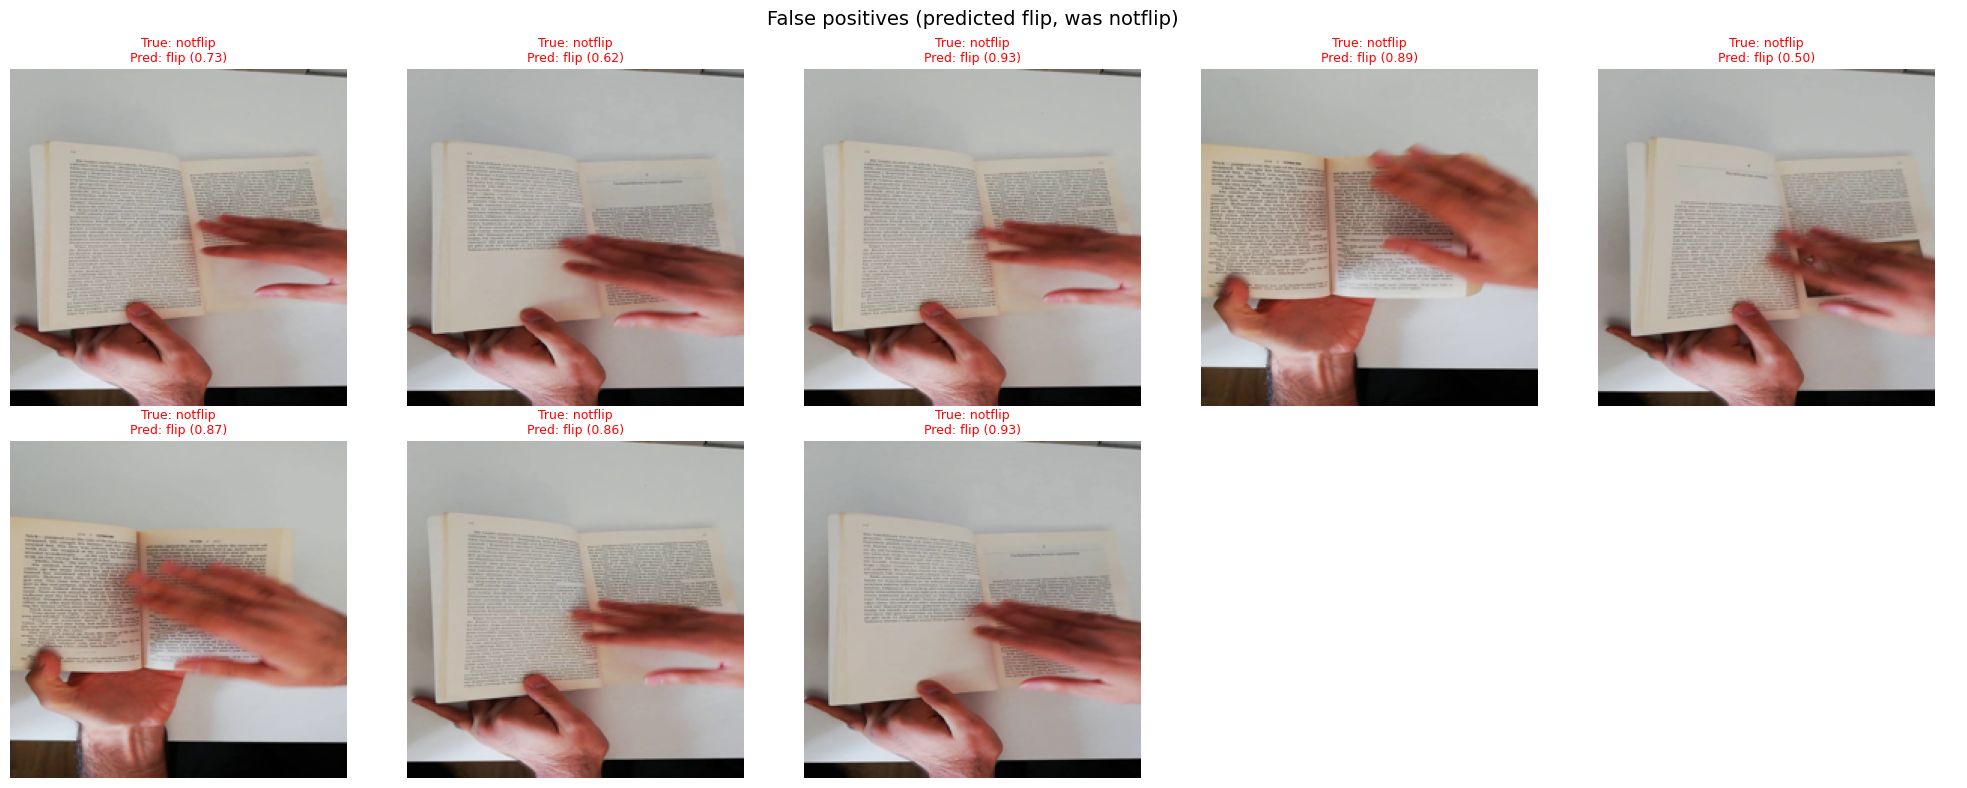

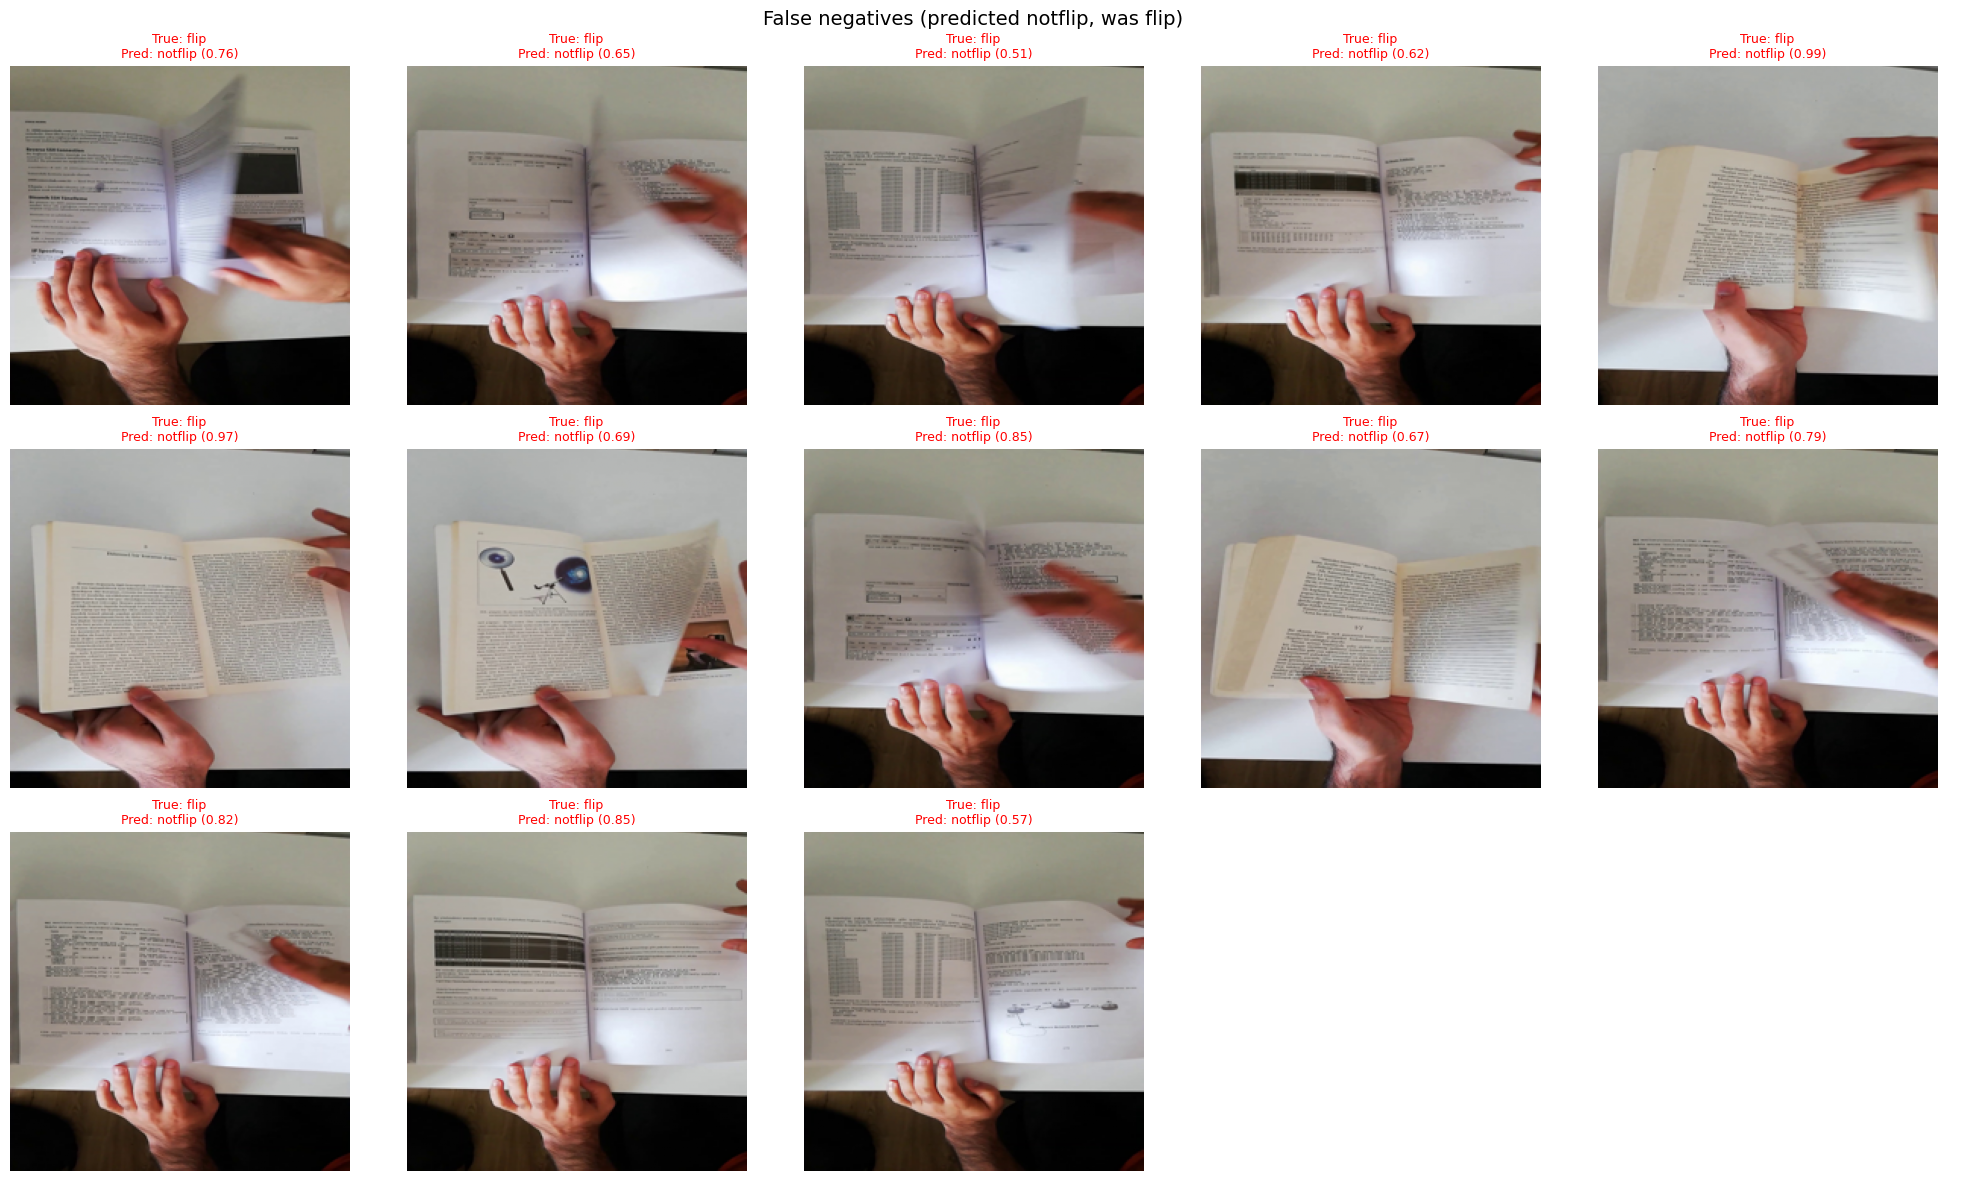

In [ ]:
def plot_misclassified_grid(images, true_labels, pred_probs, indices,
                             title='Misclassified frames', max_show=20):
    n     = min(len(indices), max_show)
    ncols = 5
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 4))
    axes      = axes.flat
    fig.suptitle(title, fontsize=14)

    for i, idx in enumerate(indices[:n]):
        ax   = axes[i]
        true = 'flip' if true_labels[idx] == 1 else 'notflip'
        pred = 'flip' if pred_probs[idx] >= 0.5 else 'notflip'
        conf = pred_probs[idx] if pred_probs[idx] >= 0.5 else 1 - pred_probs[idx]

        ax.imshow(images[idx])
        ax.set_title(f'True: {true}\nPred: {pred} ({conf:.2f})',
                     fontsize=9, color='red')
        ax.axis('off')

    # Hide unused axes
    for j in range(i + 1, nrows * ncols):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}.png', dpi=100, bbox_inches='tight')
    plt.show()

plot_misclassified_grid(test_images, y_true, y_pred_prob,
                        false_positives, title='False positives (predicted flip, was notflip)')
plot_misclassified_grid(test_images, y_true, y_pred_prob,
                        false_negatives, title='False negatives (predicted notflip, was flip)')

# Augmentation


In [ ]:
model2 = Sequential([
    Input(shape=(224,224,3)), # Explicitly define input layer
    Conv2D(64, (3,3), activation='relu'), # Remove input_shape from Conv2D
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 222, 222, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 111, 111, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │    11,944,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,983,297 (45.71 MB)

 Trainable params: 11,983,041 (45.71 MB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # lower LR
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
BATCH_SIZE = 32
EPOCHS     = 10

datagen = ImageDataGenerator(
    rotation_range=5,           # Reduced from 15
    width_shift_range=0.05,     # Reduced from 0.1
    height_shift_range=0.05,    # Reduced from 0.1
    horizontal_flip=False,      # Disabled for now, as flip might be directional
    brightness_range=[0.9, 1.1],# Reduced from [0.7, 1.3]
    zoom_range=0.05,            # Reduced from 0.15
    shear_range=0.05,           # Reduced from 0.1
    fill_mode='nearest'
)

In [ ]:
history = model.fit(
    datagen.flow(train_images, train_labels, batch_size=BATCH_SIZE),
    steps_per_epoch=int(np.ceil(len(train_images) / BATCH_SIZE)),
    epochs=EPOCHS,
    validation_data=(val_images, val_labels) # Pass validation data directly
)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 284s 5s/step - accuracy: 0.4909 - loss: 0.6935 - val_accuracy: 0.4864 - val_loss: 74.4214
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 278s 5s/step - accuracy: 0.5206 - loss: 0.6868 - val_accuracy: 0.4864 - val_loss: 123.5281
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 280s 5s/step - accuracy: 0.5191 - loss: 0.6920 - val_accuracy: 0.4864 - val_loss: 55.5524
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 291s 5s/step - accuracy: 0.5201 - loss: 0.6867 - val_accuracy: 0.4864 - val_loss: 154.6607
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 308s 5s/step - accuracy: 0.5154 - loss: 0.6882 - val_accuracy: 0.4864 - val_loss: 69.5522
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 280s 5s/step - accuracy: 0.5191 - loss: 0.6875 - val_accuracy: 0.4864 - val_loss: 66.7109
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 322s 5s/step - accuracy: 0.5212 - loss: 0.6885 - val_accuracy: 0.4280 - val_loss: 6.5913
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 275s 5s/step - accuracy: 0.5191 - loss: 0.6866 - val_accuracy: 0.

* It seems that even with the adjusted data augmentation, the custom CNN is still not learning effectively, performing no better than random chance. This indicates that the model might not be robust enough to learn the complex features needed for this task from scratch with your dataset size.



# Overview

This project focuses on **Page-Flip Detection** for MonReader, a mobile document digitization experience designed for the blind, researchers, and others needing fast, high-quality document scanning. The core idea is to automatically detect page flips from low-resolution camera previews to trigger high-resolution image capture and subsequent processing (cropping, dewarping, text recognition, and ML-powered redaction).

**Project Goal:** To predict if a page is being flipped using a single image.

**Data:**
- The dataset consists of images extracted from page-flipping videos, labeled as 'flip' or 'notflip'.
- Data was downloaded from Google Drive as `monreader_data.zip` and extracted.
- **Training set:** 2392 images (1230 'notflip', 1162 'flip').
- **Testing set:** 597 images (307 'notflip', 290 'flip').
- Images are RGB, initially (1080, 1920), resized to (224, 224), and normalized to pixel values between 0 and 1.

**Approach & Models:**
1.  **Custom CNN Model (Initial):**
    - A sequential CNN with two Conv2D (64 filters, 3x3 kernel, 'relu'), MaxPooling2D, Flatten, and two Dense layers (64 'relu', 1 'sigmoid').
    - Achieved very high performance (Test accuracy: ~0.99, F1 Score: ~0.99).
    - **Insight from Saliency Maps:** Analysis revealed the model was focusing on hands and wrist areas rather than actual page motion. This indicated a potential spurious correlation, where the model learned "hand present = notflip" as a shortcut, raising concerns about its generalization capability to diverse scenarios.

2.  **Custom CNN Model (with Augmentation):**
    - An improved custom CNN with BatchNormalization and Dropout layers.
    - Trained with adjusted, less aggressive data augmentation (rotation, shift, brightness, zoom, shear).
    - **Result:** This model performed poorly, failing to learn effectively and showing performance no better than random chance.


# Project Insights and Recommendations

## Insights from the Current Approach:

1.  **Initial Model Performance (Custom CNN without Augmentation):** The first custom CNN achieved exceptionally high accuracy (Test accuracy: ~0.99, F1 Score: ~0.99). This performance initially suggested a successful model for page-flip detection.

2.  **Saliency Map Revelation - Spurious Correlation:** Despite high accuracy, saliency map analysis revealed a critical flaw: the model was primarily focusing on the presence of hands and wrists, particularly in the 'notflip' class. It learned a shortcut, effectively associating "hands present = notflip" rather than understanding the subtle visual cues of an actual page flip. This means the model was likely overfitting to an artifact in the dataset rather than learning generalizable features related to page motion.

3.  **Failure of Augmented Model:** An attempt to improve robustness using data augmentation (even with less aggressive parameters) resulted in a complete failure of the model to learn. This indicates that either the model architecture is not robust enough to handle the increased variability introduced by augmentation, or the dataset, even with augmentation, is insufficient for the model to learn the complex, non-spurious features required.

4.  **Dataset Limitations:** The dataset, while labeled, may inadvertently contain biases or lack the diversity needed to prevent the model from latching onto simple, yet misleading, patterns.

## Recommendations:

1.  **Refine Data Augmentation Strategy:**
    *   **Motion-specific augmentation:** Explore augmentations that simulate various page-flipping motions, blurs, and speeds, rather than just geometric transformations. This could involve techniques like motion blur, optical flow, or even synthetic data generation.
    *   **Contextual augmentation:** Introduce variations in hand positions, book types, lighting, and backgrounds to force the model to look beyond simple hand detection.
    *   **Targeted augmentation:** Consider applying different augmentation strategies to 'flip' and 'notflip' classes if specific weaknesses are identified.

2.  **Focus on True Motion Features:**
    *   **Temporal information:** The current model uses single images. Incorporating temporal information (i.e., using sequences of images) is crucial for true motion detection. This would involve using models like LSTMs or 3D CNNs to analyze frame-to-frame changes.
    *   **Optical Flow:** Extract optical flow features as inputs, which directly capture motion vectors between frames. This would provide the model with explicit motion information.

3.  **Advanced Interpretability & Debugging:**
    *   **Grad-CAM/LIME:** Continue using and exploring other interpretability techniques to monitor what the model is focusing on during training, especially with new augmentations or architectures.
    *   **Adversarial Examples:** Generate adversarial examples to probe model weaknesses and identify features it incorrectly relies upon.

5.  **Dataset Expansion and Curation:**
    *   **Diversity:** Actively seek or generate data that explicitly reduces the spurious correlation observed (e.g., 'notflip' images without hands, 'flip' images with different hand placements).
    *   **Annotation Refinement:** Review existing annotations for ambiguity, especially for borderline cases between 'flip' and 'notflip'.

By addressing these recommendations, the goal is to develop a page-flip detection model that is not only accurate but also robust and genuinely learns to identify the physical act of page-flipping rather than relying on superficial cues.